# QUANSKILL AI ENGINEER FOUNDATION | MINI-PROJECT 1

* **Họ và tên:** Nguyễn Hữu Anh Khoa  
* **Lớp:** K9 - AI Engineer Foundation
* **Tên dự án:** Phân tích hành vi và Dự đoán khách hàng rời bỏ dịch vụ (Telco Customer Churn Analysis & Prediction)

### 🔹 Thiết lập thư viện và Tải dữ liệu
* Thiết lập môi trường (sử dụng uv vì đây là trình quản lý nhanh và tốt nhất của python ở thời điểm hiện tại), khai báo và cấu hình các thư viện bổ trợ (NumPy, Pandas, Matplotlib)
* Tải tập dữ liệu thô Telco Customer Churn từ nguồn cấp vào hệ thống.

### 🔹 MODULE 1: NUMPY
* Thực thi 10 bài toán thao tác mảng, tính toán thống kê, vectorization nâng cao (PCA, SVD, Euclidean Distance, Cosine Similarity).

### 🔹 MODULE 2: MATHEMATICS FOR AI 
* Triển khai 10 bài toán nền tảng tối ưu hóa đại số, xác suất Bayes, đạo hàm hàm mất mát và tự cài đặt thuật toán Gradient Descent

### 🔹 MODULE 3: PANDAS 
* Thực hiện 10 bước làm sạch dữ liệu, xử lý giá trị khuyết thiếu, kỹ nghệ đặc trưng và trực quan hóa insights bằng biểu đồ đồ họa.

### Thiết lập thư viện

In [83]:
!uv pip install matplotlib # Cài đặt matplotlib để vẽ đồ thị
!uv pip install numpy # Cài đặt numpy để xử lý dữ liệu
!uv pip install pandas # Cài đặt pandas để xử lý dữ liệu dạng bảng

Using Python 3.13.13 environment at: /home/khoa/Workspaces/Quanskill-MiniProjcets/Telco-Customers-Churn/.venv
Checked 1 package in 2ms
Using Python 3.13.13 environment at: /home/khoa/Workspaces/Quanskill-MiniProjcets/Telco-Customers-Churn/.venv
Checked 1 package in 0.96ms
Using Python 3.13.13 environment at: /home/khoa/Workspaces/Quanskill-MiniProjcets/Telco-Customers-Churn/.venv
Checked 1 package in 2ms


### Khai báo các thư viện sử dụng

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load dữ liệu

In [85]:
df = pd.read_csv('../data/raw/Telco Customer Churn.csv')
# Kiểm tra dữ liệu đã được load chưa
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [87]:
# Do dữ liệu của cột totalCharges có là kiểu dữ liệu string và có một số giá trị không phải số, nên chúng ta cần chuyển đổi nó về dạng số để có thể xử lý được.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
) 

df = df.dropna(subset=["TotalCharges"])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### MODULE 1: NUMPY

Q1.Load the dataset into a NumPy array using numerical features only (tenure, MonthlyCharges,TotalCharges). Check the shape and dtype of the array.

In [88]:
array = np.array([df['tenure'], df['MonthlyCharges'], df['TotalCharges']]).T
print(f"Array:\n{array}")
print(f"Shape of the array: {array.shape}")
print(f"Dtype of the array: {array.dtype}")

Array:
[[1.0000e+00 2.9850e+01 2.9850e+01]
 [3.4000e+01 5.6950e+01 1.8895e+03]
 [2.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [1.1000e+01 2.9600e+01 3.4645e+02]
 [4.0000e+00 7.4400e+01 3.0660e+02]
 [6.6000e+01 1.0565e+02 6.8445e+03]]
Shape of the array: (7032, 3)
Dtype of the array: float64


Q2.Compute the Mean, Median, and Standard Deviation for the columns tenure, MonthlyCharges, and TotalCharges using NumPy functions.

In [89]:
mean = np.mean(array, axis=0)
median = np.median(array, axis=0)
std = np.std(array, axis=0)
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std}")


Mean: [  32.42178612   64.79820819 2283.30044084]
Median: [  29.      70.35  1397.475]
Standard Deviation: [  24.54351439   30.08383459 2266.61018071]


Q3.Apply Min-Max normalization to scale all numerical features to the range [0,1] using vectorized operations.

In [90]:
array_min = array.min(axis=0)
array_max = array.max(axis=0)
array_norm = (array - array_min) / (array_max - array_min)
print(f"After Min Max Normalization:\n{array_norm}")
print(f"Min per column: {array_norm.min(axis=0)}")
print(f"Max per column: {array_norm.max(axis=0)}")

After Min Max Normalization:
[[0.         0.11542289 0.0012751 ]
 [0.46478873 0.38507463 0.21586661]
 [0.01408451 0.35422886 0.01031041]
 ...
 [0.14084507 0.11293532 0.03780868]
 [0.04225352 0.55870647 0.03321025]
 [0.91549296 0.86965174 0.78764136]]
Min per column: [0. 0. 0.]
Max per column: [1. 1. 1.]


Q4. Use boolean indexing to filter customers with tenure > 12 and MonthlyCharges greater than the dataset average.

In [91]:
mask = (array[:, 0] > 12) & (array[:, 1] > df.MonthlyCharges.mean())

print(f"Mask:\n{mask}")

Mask:
[False False False ... False False  True]


Q5. Compute the correlation matrix between numerical features using NumPy (without using Pandas).

In [92]:
correlation_matrix = np.corrcoef(array, rowvar=False)
print(f"Correlation Matrix:\n{correlation_matrix}")

Correlation Matrix:
[[1.         0.24686177 0.82588046]
 [0.24686177 1.         0.6510648 ]
 [0.82588046 0.6510648  1.        ]]


Vectorization & Linear Algebra

Q6. Implement a fully vectorized function to compute pairwise Euclidean distance between customers using numerical features only (avoid explicit Python loops).

In [93]:
def pairwise_euclidean(array):
    sq_norms = np.sum(array**2, axis=1, keepdims=True)
    inside_sqrt = sq_norms + sq_norms.T - 2 * np.dot(array, array.T)
    # Đảm bảo không có giá trị âm
    inside_sqrt = np.clip(inside_sqrt, a_min=0, a_max=None)
    dist_matrix = np.sqrt(inside_sqrt)
    return dist_matrix

In [94]:
print(f"Pairwise Euclidean Distance Matrix:\n{pairwise_euclidean(array)}")

Pairwise Euclidean Distance Matrix:
[[   0.         1860.14019163   81.90170938 ...  316.75798727
   280.32885153 6815.38151995]
 [1860.14019163    0.         1781.64009623 ... 1543.46374269
  1583.28042762 4955.34264103]
 [  81.90170938 1781.64009623    0.         ...  239.69971318
   199.52118935 6736.85316468]
 ...
 [ 316.75798727 1543.46374269  239.69971318 ...    0.
    60.36607077 6498.7277528 ]
 [ 280.32885153 1583.28042762  199.52118935 ...   60.36607077
     0.         6538.26865252]
 [6815.38151995 4955.34264103 6736.85316468 ... 6498.7277528
  6538.26865252    0.        ]]


Q7. Implement both Min-Max scaling and Z-score normalization from scratch using NumPy and compare their results.

In [95]:
def z_score_normalize(array):
    return (array - np.mean(array, axis=0)) / np.std(array, axis=0)

In [96]:
print (f"Z-score Normalized Array:\n{z_score_normalize(array)}")

Z-score Normalized Array:
[[-1.28024804 -1.16169394 -0.99419409]
 [ 0.06430269 -0.26087792 -0.17373982]
 [-1.23950408 -0.36392329 -0.95964911]
 ...
 [-0.87280842 -1.17000405 -0.85451414]
 [-1.15801615  0.31916782 -0.87209546]
 [ 1.36810945  1.35793167  2.01234407]]


In [97]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

In [98]:
sim = cosine_similarity(array[0], array[1])
print(f"Cosine Similarity between first two customers: {sim}")

Cosine Similarity between first two customers: 0.7281924923197327


Q9. Perform PCA manually using NumPy: construct the covariance matrix from numerical features, compute eigenvalues and eigenvectors, and project the data onto the top 2 principal components.

In [99]:
def PCA(array, components=2):
    """
    Các bước xử lý:
    1. Standardize -> 2. Covariance matrix -> 3. Eigenvalues & Eigenvectors -> 4. Sort descending -> 5. Select components -> 6. Result
    """
    mean = np.mean(array, axis=0)
    std = np.std(array, axis=0)
    std[std == 0] = 1
    array_normalized = (array - mean) / std

    covariance_matrix = np.cov(array_normalized, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    selected_eigenvectors = sorted_eigenvectors[:, :components]
    transformed_data = np.dot(array_normalized, selected_eigenvectors)
    
    return transformed_data


In [100]:
pca = PCA(array, components=2)
print(f"PCA: \n{pca}")

PCA: 
[[ 1.95165689  0.08275258]
 [ 0.20579255  0.23514165]
 [ 1.51808264 -0.52254219]
 ...
 [ 1.63168822  0.34516629]
 [ 1.08184347 -1.00900265]
 [-2.77397648 -0.12278947]]


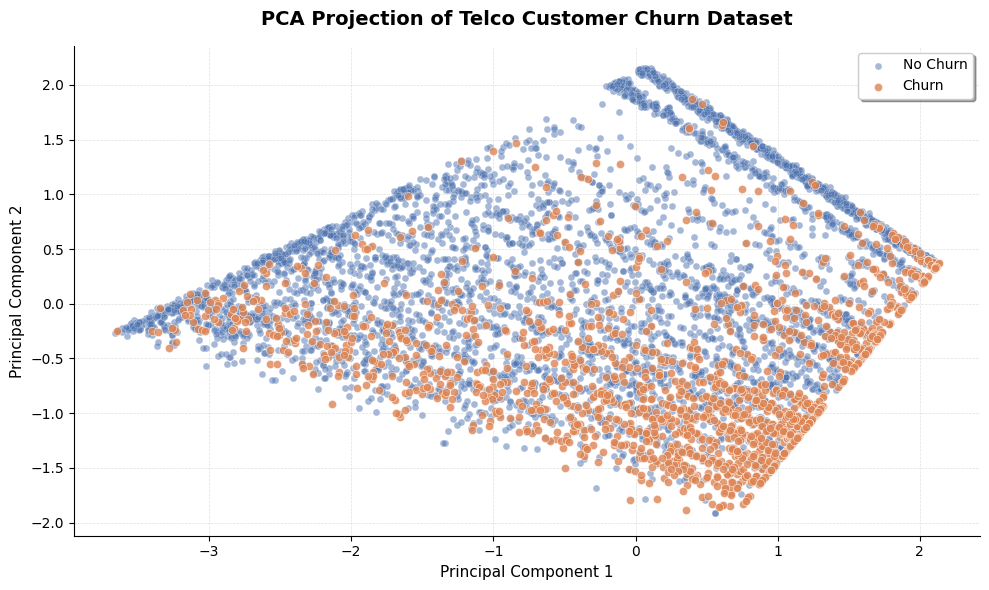

In [103]:
# Vẽ biểu đồ phân tán của dữ liệu sau khi đã được giảm chiều bằng PCA
fig, ax = plt.subplots(figsize=(10, 6))

y = df["Churn"].to_numpy()

ax.scatter(
    pca[y == "No", 0],
    pca[y == "No", 1],
    s=25,
    alpha=0.5,
    c="#4C72B0",
    edgecolors="white",
    linewidth=0.3,
    label="No Churn",
)

ax.scatter(
    pca[y == "Yes", 0],
    pca[y == "Yes", 1],
    s=35,
    alpha=0.8,
    c="#DD8452",
    edgecolors="white",
    linewidth=0.4,
    label="Churn",
)

ax.set_xlabel(
    f"Principal Component 1", fontsize=11
)

ax.set_ylabel(
    f"Principal Component 2", fontsize=11
)

ax.set_title(
    "PCA Projection of Telco Customer Churn Dataset",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.grid(linestyle="--", linewidth=0.5, alpha=0.4)

# Legend
ax.legend(frameon=True, fancybox=True, shadow=True)

# Remove top/right border
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../output/figures/m1_q9_pca.png", dpi=300, bbox_inches="tight")

plt.show()

Q10. Implement batch processing by splitting the NumPy array into equal-sized batches and computing the mean vector for each batch.

In [104]:
# Kích thước batch
batch_size = 700
batches = np.array_split(array, len(array) // batch_size)

print(f"Number of batches: {len(batches)}")
print(f"Shape of first batch: {batches[0].shape}") 
print(f"First batch:\n{batches[0]}")

Number of batches: 10
Shape of first batch: (704, 3)
First batch:
[[1.0000e+00 2.9850e+01 2.9850e+01]
 [3.4000e+01 5.6950e+01 1.8895e+03]
 [2.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [2.9000e+01 8.4900e+01 2.5162e+03]
 [2.0000e+00 2.0550e+01 3.3600e+01]
 [4.0000e+00 4.9250e+01 2.0845e+02]]


In [105]:
mean_batch = np.mean(batches[0], axis=0)
print(f"Mean of the first batch:\n{mean_batch}")

Mean of the first batch:
[  32.05965909   66.39921875 2315.23877841]


End of Q1